# Introducción al análisis estadístico 
Este notebook contiene el análisis estadístico descriptivo de las
variables registradas por la estación ambiental durante el periodo
de monitorización.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


# Descripción del conjunto de datos 

In [4]:
#Importo los datos de mi excel 
df_ambiente= pd.read_csv('prueba2.csv', sep=',', header=None)
df_week_40=pd.read_csv('s40.csv', sep=',', header=None)
#Miro como son mis columnas 
df_ambiente.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,#group,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false
1,#datatype,double,double,double,double,double,double,double,double,long,long,double,long,double,double,double,double,dateTime:RFC3339
2,#default,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,bvoc,co2eq,gas,gas_resistencia,hum,humedad,iaq,lux,pm10_0,pm1_0,pm25_pred_1h,pm2_5,pres,presion,temp,temperatura,time
4,NaN,NaN,NaN,27.7,NaN,81.4,NaN,NaN,1.67,4,2,NaN,3,1018.05,NaN,16.75,NaN,2025-10-06T00:01:49.804443847Z


In [5]:
df_ambiente.shape



(8585, 18)

In [6]:

df_ambiente.dtypes

0     object
1     object
2     object
3     object
4     object
5     object
6     object
7     object
8     object
9     object
10    object
11    object
12    object
13    object
14    object
15    object
16    object
17    object
dtype: object

In [7]:
df_ambiente.isna().sum()

0     8582
1     8582
2     8582
3      881
4     8582
5      881
6     8582
7     8582
8      881
9      881
10     881
11    7702
12     881
13     881
14    8582
15     881
16    8582
17       1
dtype: int64

In [8]:
df_ambiente = df_ambiente.drop(df_ambiente.columns[[0,1,2,4,6,7,11,14,16]], axis=1)

df_ambiente = df_ambiente.drop(df_ambiente.index[[0,1,2]], axis=0)

df_ambiente

,3,5,8,9,10,12,13,15,17
3,gas,hum,lux,pm10_0,pm1_0,pm2_5,pres,temp,time
4,27.7,81.4,1.67,4,2,3,1018.05,16.75,2025-10-06T00:01:49.804443847Z
5,26.85,81.16,0.83,5,3,4,1018.16,16.61,2025-10-06T00:07:22.185193661Z
6,27.34,79.99,1.67,5,3,4,1018.21,16.49,2025-10-06T00:12:55.194415384Z
7,31.19,74.74,1.67,5,3,4,1018.27,16.43,2025-10-06T00:18:28.510440004Z
...,...,...,...,...,...,...,...,...,...
8580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:25:00Z
8581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:30:00Z
8582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:35:00Z
8583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:40:00Z


In [9]:
nombres_columnas = ['gas','humedad','lux','pm10','pm1','pm2.5','presion','temp','Fecha/hora']
df_ambiente.columns = nombres_columnas
# Elimino la fila 0 porque ya tenia los nombres que yo queria 
df_ambiente = df_ambiente.drop(df_ambiente.index[[0]], axis=0)
df_ambiente

,gas,humedad,lux,pm10,pm1,pm2.5,presion,temp,Fecha/hora
4,27.7,81.4,1.67,4,2,3,1018.05,16.75,2025-10-06T00:01:49.804443847Z
5,26.85,81.16,0.83,5,3,4,1018.16,16.61,2025-10-06T00:07:22.185193661Z
6,27.34,79.99,1.67,5,3,4,1018.21,16.49,2025-10-06T00:12:55.194415384Z
7,31.19,74.74,1.67,5,3,4,1018.27,16.43,2025-10-06T00:18:28.510440004Z
8,41.54,69.17,1.67,4,2,3,1018.32,16.43,2025-10-06T00:24:01.520771861Z
...,...,...,...,...,...,...,...,...,...
8580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:25:00Z
8581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:30:00Z
8582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:35:00Z
8583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:40:00Z


In [10]:
df_week_40 = df_week_40.drop(df_week_40.columns[[0,1,2,4,6,7,13,15]], axis=1)
df_week_40 = df_week_40.drop(df_week_40.index[[0,1,2]], axis=0)

In [11]:
nombres_columnas = ['gas','humedad','lux','pm10','pm1','pm2.5','presion','temp','Fecha/hora']
df_week_40.columns = nombres_columnas

df_week_40 = df_week_40.drop(df_ambiente.index[[0]], axis=0)
df_week_40

,gas,humedad,lux,pm10,pm1,pm2.5,presion,temp,Fecha/hora
3,gas,hum,lux,pm10_0,pm1_0,pm2_5,pres,temp,time
5,19.84,75.3,0.83,17,12,16,1014.07,19.62,2025-09-30T00:07:10.215775097Z
6,19.79,74.47,0.83,17,11,15,1014.05,19.62,2025-09-30T00:12:47.292697787Z
7,19.94,74.01,0.83,16,12,15,1014.03,19.61,2025-09-30T00:18:19.300693929Z
8,20.35,73.77,0.83,16,12,15,1014,19.6,2025-09-30T00:23:51.395464121Z
...,...,...,...,...,...,...,...,...,...
1803,30.8,72.47,0.83,14,10,13,1016.12,21.29,2025-10-02T23:33:50.851340875Z
1804,30.03,72.77,0.83,12,9,12,1016.16,21.19,2025-10-02T23:39:23.771511753Z
1805,28.51,74.13,0.83,14,9,12,1016.2,21.02,2025-10-02T23:44:56.40615835Z
1806,26.53,73.81,0.83,14,10,13,1016.26,20.85,2025-10-02T23:50:28.642935837Z


In [12]:
print(df_week_40.columns)
print(df_ambiente.columns)


df_week_40.columns = df_ambiente.columns  


df_completo = pd.concat([df_week_40, df_ambiente], axis=0, ignore_index=True)



Index(['gas', 'humedad', 'lux', 'pm10', 'pm1', 'pm2.5', 'presion', 'temp',
       'Fecha/hora'],
      dtype='object')
Index(['gas', 'humedad', 'lux', 'pm10', 'pm1', 'pm2.5', 'presion', 'temp',
       'Fecha/hora'],
      dtype='object')


In [13]:
df_completo['Fecha/hora'] = pd.to_datetime(df_completo['Fecha/hora'], errors='coerce')
df_completo['Fecha/hora'] = df_completo['Fecha/hora'].dt.tz_localize(None)          
df_completo['Fecha/hora'] = df_completo['Fecha/hora'].dt.floor('s')   
df_completo = df_completo.sort_values(by='Fecha/hora', ascending=True)


print(df_completo.head())

       gas humedad   lux pm10 pm1 pm2.5  presion   temp          Fecha/hora
771  17.92   76.81  0.83   30  18    27  1012.43   20.8 2025-09-28 22:00:44
772  17.86   77.07  0.83   33  18    28  1012.44  20.75 2025-09-28 22:06:16
773  17.85   77.17  0.83   31  18    27  1012.47  20.69 2025-09-28 22:11:49
774  17.71   77.09  0.83   31  19    27   1012.5  20.66 2025-09-28 22:17:22
775  17.74   76.98  0.83   32  18    27  1012.53  20.65 2025-09-28 22:22:54


C:\Users\aleoj\AppData\Local\Temp\ipykernel_19312\3949810343.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_completo['Fecha/hora'] = pd.to_datetime(df_completo['Fecha/hora'], errors='coerce')


In [14]:

df_completo['Fecha/hora'] = pd.to_datetime(df_completo['Fecha/hora'])


inicio_datos = pd.to_datetime('2025-09-29 00:00:00')  
final_datos = pd.to_datetime('2025-10-26 23:59:59')   


df_completo = df_completo[
    (df_completo['Fecha/hora'] >= inicio_datos) &
    (df_completo['Fecha/hora'] <= final_datos)
]


df_completo = df_completo.sort_values(by='Fecha/hora')


print(df_completo.head())



       gas humedad   lux pm10 pm1 pm2.5  presion   temp          Fecha/hora
514   16.1   80.73  0.83   20  14    19  1012.23  19.81 2025-09-29 00:02:53
515  16.22   80.81  0.83   22  14    20  1012.23  19.77 2025-09-29 00:08:26
516  16.02   80.96  0.83   22  14    20  1012.25  19.73 2025-09-29 00:13:58
517   15.8   80.77  0.83   25  16    22  1012.28   19.7 2025-09-29 00:19:31
518   15.8   80.58  0.83   22  15    20   1012.3  19.69 2025-09-29 00:25:11


In [15]:
df_completo.dtypes

gas                   object
humedad               object
lux                   object
pm10                  object
pm1                   object
pm2.5                 object
presion               object
temp                  object
Fecha/hora    datetime64[ns]
dtype: object

In [16]:
df_completo.isna().sum()

gas           0
humedad       0
lux           0
pm10          0
pm1           0
pm2.5         0
presion       0
temp          0
Fecha/hora    0
dtype: int64

In [17]:
rows_with_nan = df_completo[df_completo.isna().any(axis=1)]

print(rows_with_nan[['Fecha/hora']])


Empty DataFrame
Columns: [Fecha/hora]
Index: []


In [18]:
nan_by_date = df_completo.groupby(df_completo['Fecha/hora'].dt.date).apply(lambda x: x.isna().sum())
print(nan_by_date)


            gas  humedad  lux  pm10  pm1  pm2.5  presion  temp  Fecha/hora
Fecha/hora                                                                
2025-09-29    0        0    0     0    0      0        0     0           0
2025-09-30    0        0    0     0    0      0        0     0           0
2025-10-01    0        0    0     0    0      0        0     0           0
2025-10-02    0        0    0     0    0      0        0     0           0
2025-10-03    0        0    0     0    0      0        0     0           0
2025-10-04    0        0    0     0    0      0        0     0           0
2025-10-05    0        0    0     0    0      0        0     0           0
2025-10-06    0        0    0     0    0      0        0     0           0
2025-10-07    0        0    0     0    0      0        0     0           0
2025-10-08    0        0    0     0    0      0        0     0           0
2025-10-09    0        0    0     0    0      0        0     0           0
2025-10-10    0        0 

In [19]:
fecha_hora=df_completo['Fecha/hora']

df_completo = df_completo.apply(pd.to_numeric, errors='ignore')

df_completo['Fecha/hora'] = fecha_hora

df_completo.dtypes

gas                  float64
humedad              float64
lux                  float64
pm10                   int64
pm1                    int64
pm2.5                  int64
presion              float64
temp                 float64
Fecha/hora    datetime64[ns]
dtype: object

In [20]:
print(df_completo)

         gas  humedad   lux  pm10  pm1  pm2.5  presion   temp  \
514    16.10    80.73  0.83    20   14     19  1012.23  19.81   
515    16.22    80.81  0.83    22   14     20  1012.23  19.77   
516    16.02    80.96  0.83    22   14     20  1012.25  19.73   
517    15.80    80.77  0.83    25   16     22  1012.28  19.70   
518    15.80    80.58  0.83    22   15     20  1012.30  19.69   
...      ...      ...   ...   ...  ...    ...      ...    ...   
7275  118.88    71.84  0.83     3    2      3  1014.20  11.95   
7276  143.41    69.92  0.83     3    2      2  1014.21  11.96   
7277  163.57    69.40  0.83     2    1      2  1014.24  11.93   
7278  180.30    69.59  0.83     3    1      2  1014.27  11.88   
7279  190.86    68.88  0.83     2    1      1  1014.28  11.84   

              Fecha/hora  
514  2025-09-29 00:02:53  
515  2025-09-29 00:08:26  
516  2025-09-29 00:13:58  
517  2025-09-29 00:19:31  
518  2025-09-29 00:25:11  
...                  ...  
7275 2025-10-26 23:35:48  
727

In [21]:
df_EDA = df_completo.copy()


df_EDA.set_index('Fecha/hora', inplace=True)


df_EDA['week'] = df_EDA.index.isocalendar().week


print(df_EDA.tail())

                        gas  humedad   lux  pm10  pm1  pm2.5  presion   temp  \
Fecha/hora                                                                     
2025-10-26 23:35:48  118.88    71.84  0.83     3    2      3  1014.20  11.95   
2025-10-26 23:41:25  143.41    69.92  0.83     3    2      2  1014.21  11.96   
2025-10-26 23:47:00  163.57    69.40  0.83     2    1      2  1014.24  11.93   
2025-10-26 23:52:34  180.30    69.59  0.83     3    1      2  1014.27  11.88   
2025-10-26 23:58:10  190.86    68.88  0.83     2    1      1  1014.28  11.84   

                     week  
Fecha/hora                 
2025-10-26 23:35:48    43  
2025-10-26 23:41:25    43  
2025-10-26 23:47:00    43  
2025-10-26 23:52:34    43  
2025-10-26 23:58:10    43  


# Análisis del intervalo de muestreo

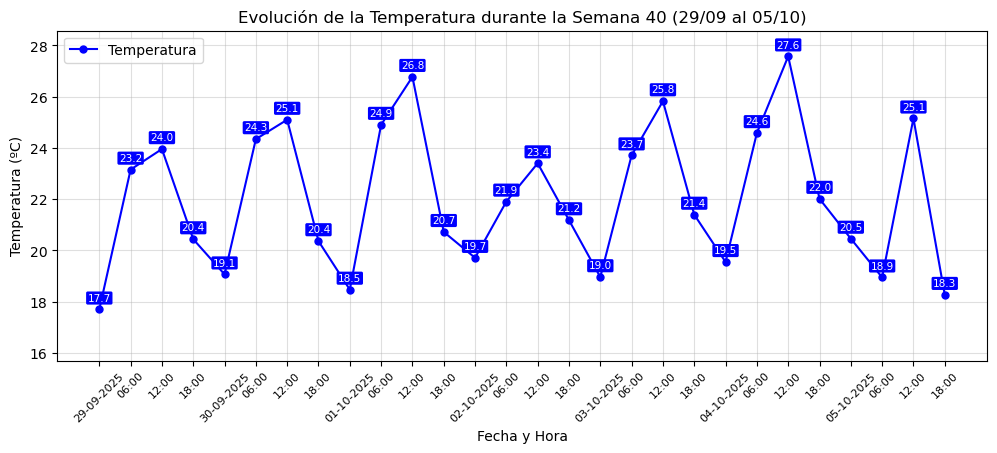

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

semana_40 = df_EDA[df_EDA['week'] == 40].copy()
semana_40.index = pd.to_datetime(semana_40.index).floor('H')


semana_40_6h = semana_40.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_40_6h.index.min()
fin = semana_40_6h.index.max()
titulo = f"Evolución de la Temperatura durante la Semana 40 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_40_6h.index,
    semana_40_6h['temp'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='Temperatura'
)


for x, y in zip(semana_40_6h.index, semana_40_6h['temp']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_40_6h['temp'].min(), semana_40_6h['temp'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Temperatura (ºC)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()


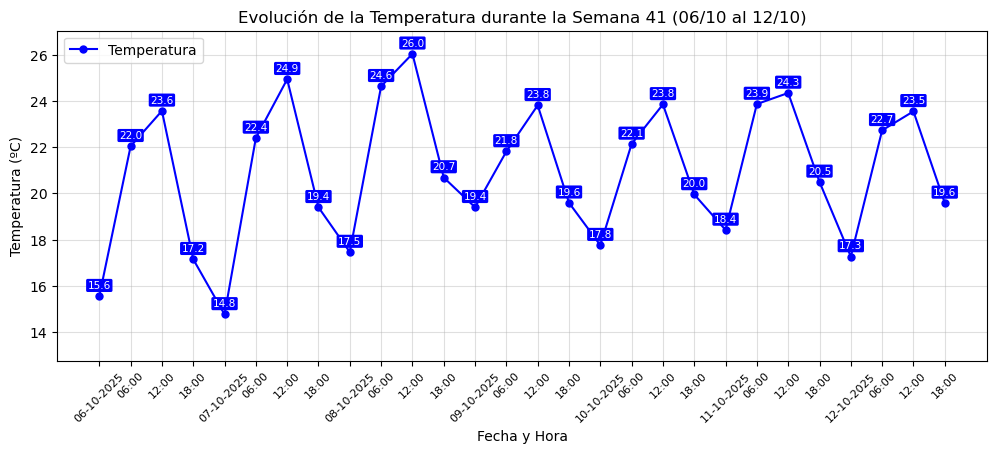

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_41 = df_EDA[df_EDA['week'] == 41].copy()
semana_41.index = pd.to_datetime(semana_41.index).floor('H')


semana_41_6h = semana_41.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_41_6h.index.min()
fin = semana_41_6h.index.max()
titulo = f"Evolución de la Temperatura durante la Semana 41 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_41_6h.index,
    semana_41_6h['temp'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='Temperatura'
)

for x, y in zip(semana_41_6h.index, semana_41_6h['temp']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )

ax.set_xticks(ticks)

def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))

ymin, ymax = semana_41_6h['temp'].min(), semana_41_6h['temp'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Temperatura (ºC)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()


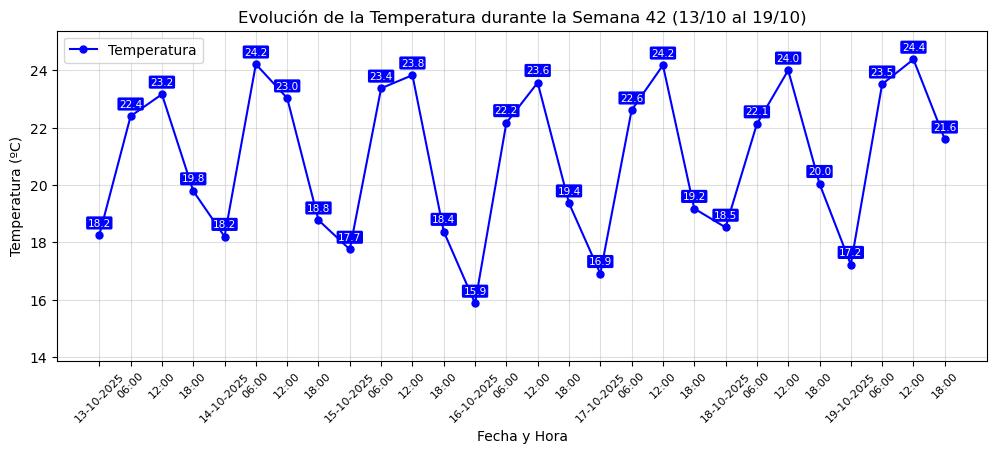

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

semana_42 = df_EDA[df_EDA['week'] == 42].copy()
semana_42.index = pd.to_datetime(semana_42.index).floor('H')


semana_42_6h = semana_42.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_42_6h.index.min()
fin = semana_42_6h.index.max()
titulo = f"Evolución de la Temperatura durante la Semana 42 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_42_6h.index,
    semana_42_6h['temp'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='Temperatura'
)

for x, y in zip(semana_42_6h.index, semana_42_6h['temp']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )

ax.set_xticks(ticks)

def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))

ymin, ymax = semana_42_6h['temp'].min(), semana_42_6h['temp'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Temperatura (ºC)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()



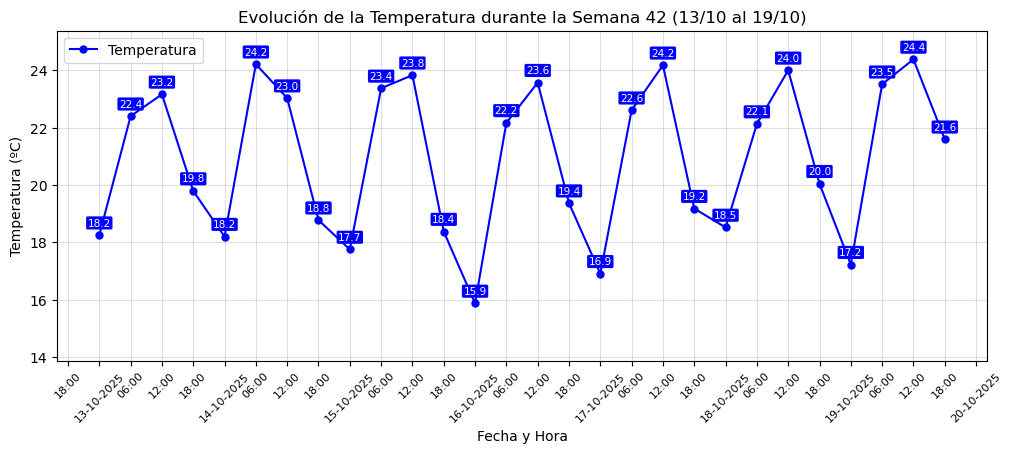

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# filtrar semana 42
semana_42 = df_EDA[df_EDA['week'] == 42].copy()
semana_42.index = pd.to_datetime(semana_42.index).floor('H')

# agrupar cada 6 h alineado al día
semana_42_6h = semana_42.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_42_6h.index.min()
fin = semana_42_6h.index.max()
titulo = f"Evolución de la Temperatura durante la Semana 42 ({ini:%d/%m} al {fin:%d/%m})"

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_42_6h.index,
    semana_42_6h['temp'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='Temperatura'
)

for x, y in zip(semana_42_6h.index, semana_42_6h['temp']):
    if pd.notna(y):
        ax.text(
            x,
            y + 0.25,
            f"{y:.1f}",
            ha='center',
            va='bottom',
            fontsize=7.5,
            color='white',
            bbox=dict(
                facecolor='blue',
                edgecolor='none',
                boxstyle='round,pad=0.15'
            )
        )

ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))

def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    return dt.strftime('%d-%m-%Y') if dt.hour == 0 else dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))

ymin, ymax = semana_42_6h['temp'].min(), semana_42_6h['temp'].max()
ax.set_ylim(ymin - 2, ymax + 1)

ax.margins(x=0.05)
ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Temperatura (ºC)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()


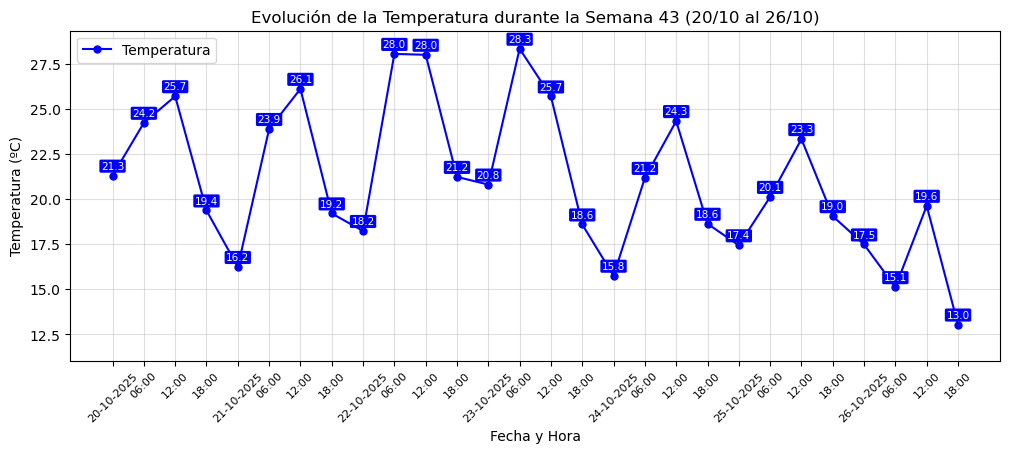

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_43 = df_EDA[df_EDA['week'] == 43].copy()
semana_43.index = pd.to_datetime(semana_43.index).floor('H')


semana_43_6h = semana_43.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_43_6h.index.min()
fin = semana_43_6h.index.max()
titulo = f"Evolución de la Temperatura durante la Semana 43 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_43_6h.index,
    semana_43_6h['temp'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='Temperatura'
)

for x, y in zip(semana_43_6h.index, semana_43_6h['temp']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )

ax.set_xticks(ticks)

def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))

ymin, ymax = semana_43_6h['temp'].min(), semana_43_6h['temp'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Temperatura (ºC)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()



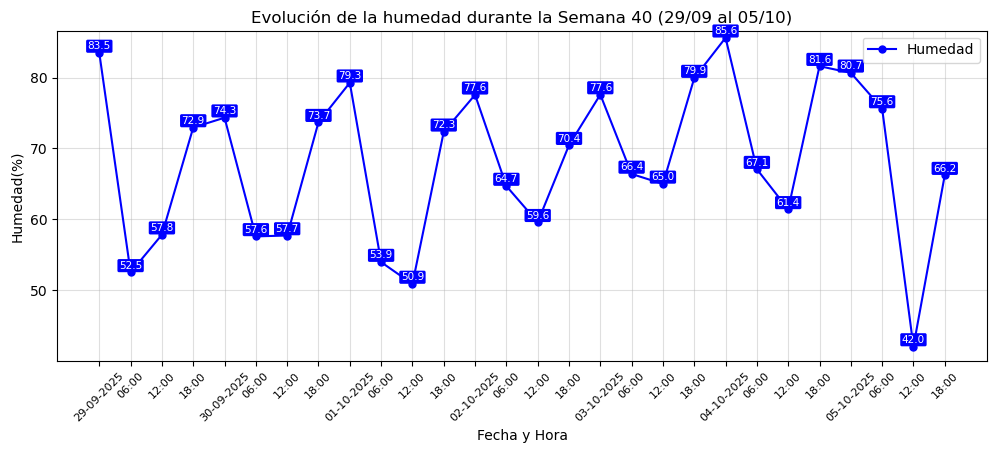

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_40 = df_EDA[df_EDA['week'] == 40].copy()


semana_40.index = pd.to_datetime(semana_40.index).floor('H')


semana_40_6h = semana_40.resample('6H', origin='start_day').mean(numeric_only=True)


ini = semana_40_6h.index.min()
fin = semana_40_6h.index.max()


titulo = f"Evolución de la humedad durante la Semana 40 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))


ax.plot(
    semana_40_6h.index,
    semana_40_6h['humedad'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='Humedad'
)


for x, y in zip(semana_40_6h.index, semana_40_6h['humedad']):
    
    if pd.notna(y):
        ax.text(
            x,                      
            y + 0.25,               
            f"{y:.1f}",             
            ha='center',            
            va='bottom',            
            fontsize=7.5,           
            color='white',          
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    
    dt = mdates.num2date(x)
 
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        
        return dt.strftime('%H:%M')


ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_40_6h['humedad'].min(), semana_40_6h['humedad'].max()

ax.set_ylim(ymin - 2, ymax + 1)

ax.margins(x=0.05)


ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Humedad(%)')

ax.legend(loc='upper right')


ax.grid(True, alpha=0.4)


plt.xticks(rotation=45, fontsize=8)


plt.subplots_adjust(bottom=0.22)


plt.show()


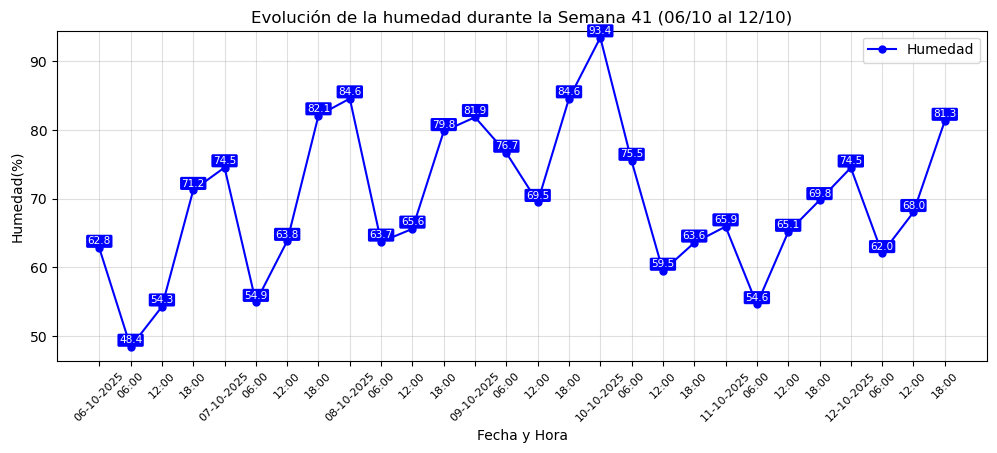

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_41 = df_EDA[df_EDA['week'] == 41].copy()


semana_41.index = pd.to_datetime(semana_41.index).floor('H')


semana_41_6h = semana_41.resample('6H', origin='start_day').mean(numeric_only=True)


ini = semana_41_6h.index.min()
fin = semana_41_6h.index.max()


titulo = f"Evolución de la humedad durante la Semana 41 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))


ax.plot(
    semana_41_6h.index,
    semana_41_6h['humedad'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='Humedad'
)


for x, y in zip(semana_41_6h.index, semana_41_6h['humedad']):
   
    if pd.notna(y):
        ax.text(
            x,                     
            y + 0.25,               
            f"{y:.1f}",             
            ha='center',           
            va='bottom',            
            fontsize=7.5,           
            color='white',       
            
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
   
    dt = mdates.num2date(x)
  
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
       
        return dt.strftime('%H:%M')


ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_41_6h['humedad'].min(), semana_41_6h['humedad'].max()


ax.set_ylim(ymin - 2, ymax + 1)


ax.margins(x=0.05)


ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Humedad(%)')


ax.legend(loc='upper right')


ax.grid(True, alpha=0.4)


plt.xticks(rotation=45, fontsize=8)


plt.subplots_adjust(bottom=0.22)


plt.show()


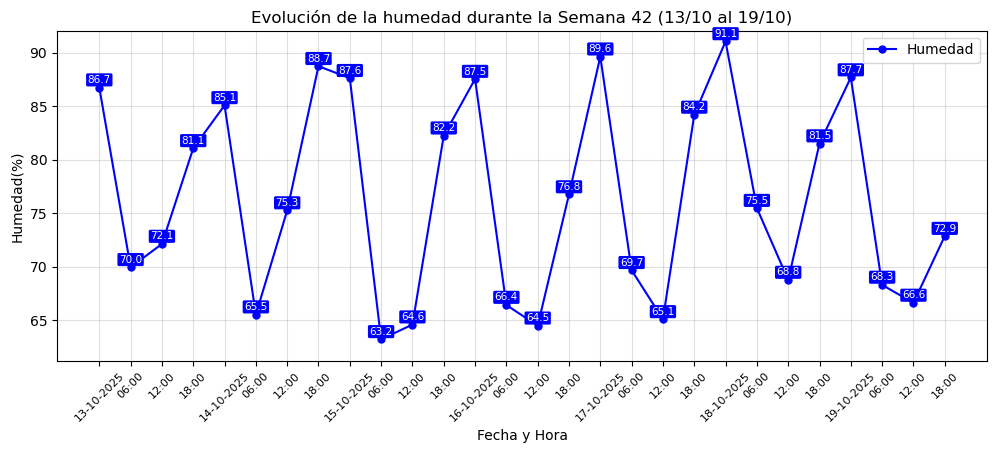

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_42 = df_EDA[df_EDA['week'] == 42].copy()


semana_42.index = pd.to_datetime(semana_42.index).floor('H')


semana_42_6h = semana_42.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_42_6h.index.min()
fin = semana_42_6h.index.max()


titulo = f"Evolución de la humedad durante la Semana 42 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))


ax.plot(
    semana_42_6h.index,
    semana_42_6h['humedad'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='Humedad'
)


for x, y in zip(semana_42_6h.index, semana_42_6h['humedad']):
    
    if pd.notna(y):
        ax.text(
            x,                      
            y + 0.25,               
            f"{y:.1f}",             
            ha='center',            
            va='bottom',           
            fontsize=7.5,           
            color='white',          
        
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    
    dt = mdates.num2date(x)
    
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
       
        return dt.strftime('%H:%M')


ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_42_6h['humedad'].min(), semana_42_6h['humedad'].max()


ax.set_ylim(ymin - 2, ymax + 1)


ax.margins(x=0.05)


ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Humedad(%)')


ax.legend(loc='upper right')


ax.grid(True, alpha=0.4)


plt.xticks(rotation=45, fontsize=8)


plt.subplots_adjust(bottom=0.22)


plt.show()


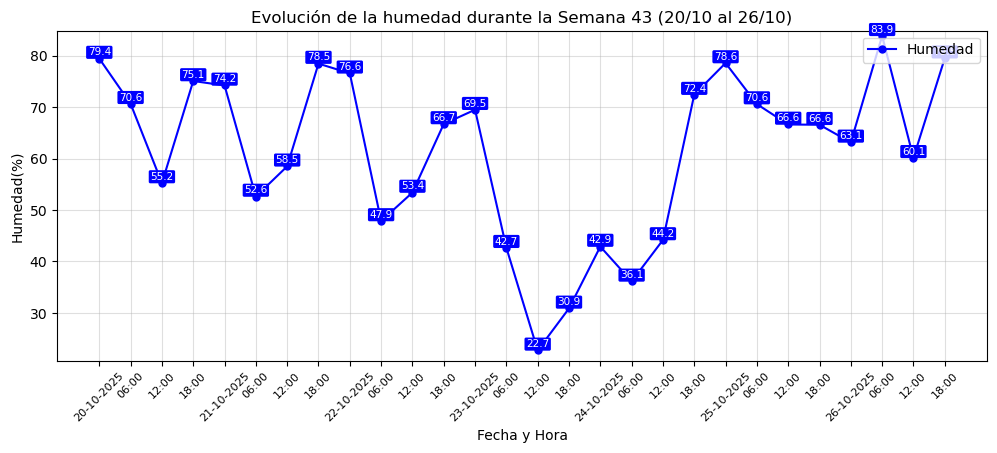

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_43 = df_EDA[df_EDA['week'] == 43].copy()


semana_43.index = pd.to_datetime(semana_43.index).floor('H')


semana_43_6h = semana_43.resample('6H', origin='start_day').mean(numeric_only=True)


ini = semana_43_6h.index.min()
fin = semana_43_6h.index.max()


titulo = f"Evolución de la humedad durante la Semana 43 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))


ax.plot(
    semana_43_6h.index,
    semana_43_6h['humedad'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='Humedad'
)


for x, y in zip(semana_43_6h.index, semana_43_6h['humedad']):
  
    if pd.notna(y):
        ax.text(
            x,                      
            y + 0.25,              
            f"{y:.1f}",             
            ha='center',            
            va='bottom',            
            fontsize=7.5,           
            color='white',         
           
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
   
    dt = mdates.num2date(x)

    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
       
        return dt.strftime('%H:%M')


ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))

ymin, ymax = semana_43_6h['humedad'].min(), semana_43_6h['humedad'].max()


ax.set_ylim(ymin - 2, ymax + 1)

ax.margins(x=0.05)


ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Humedad(%)')


ax.legend(loc='upper right')


ax.grid(True, alpha=0.4)


plt.xticks(rotation=45, fontsize=8)


plt.subplots_adjust(bottom=0.22)


plt.show()

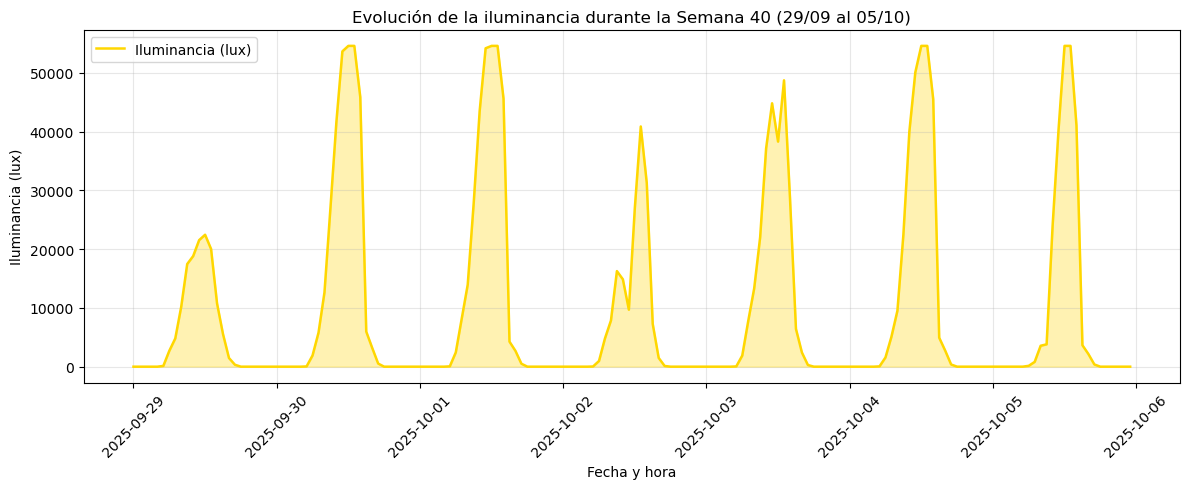

In [30]:

semana_40_1h = df_EDA[df_EDA['week'] == 40].resample('1H').mean(numeric_only=True)

ini = semana_40_1h.index.min()
fin = semana_40_1h.index.max()
titulo = f"Evolución de la iluminancia durante la Semana 40 ({ini:%d/%m} al {fin:%d/%m})"

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    semana_40_1h.index,
    semana_40_1h['lux'],
    color='gold',
    linewidth=1.8,
    label='Iluminancia (lux)'
)

ax.fill_between(semana_40_1h.index, semana_40_1h['lux'], color='gold', alpha=0.3)

ax.set_title(titulo)
ax.set_xlabel("Fecha y hora")
ax.set_ylabel("Iluminancia (lux)")
ax.grid(alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


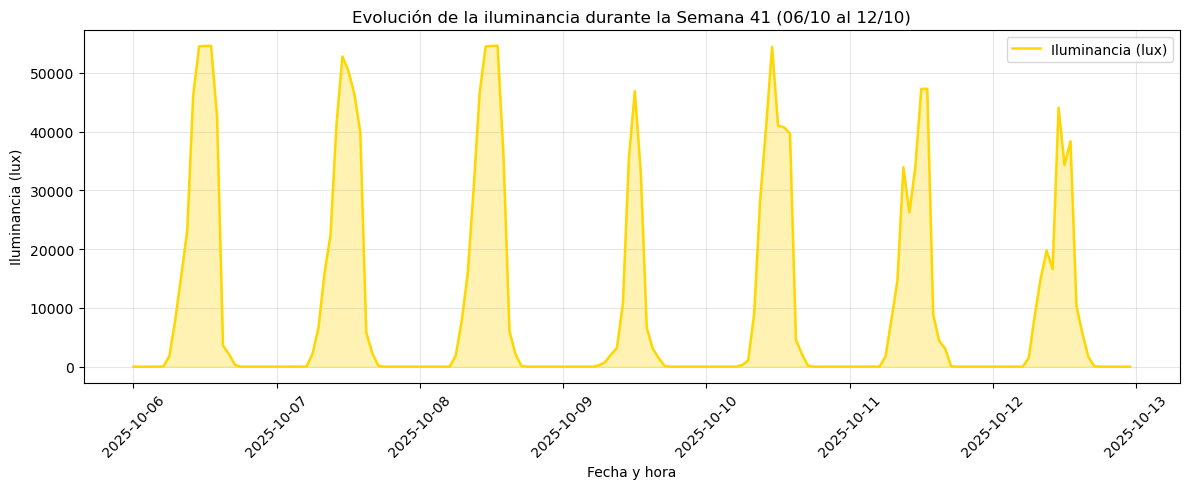

In [31]:

semana_41_1h = df_EDA[df_EDA['week'] == 41].resample('1H').mean(numeric_only=True)
ini = semana_41_1h.index.min()
fin = semana_41_1h.index.max()
titulo = f"Evolución de la iluminancia durante la Semana 41 ({ini:%d/%m} al {fin:%d/%m})"

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    semana_41_1h.index,
    semana_41_1h['lux'],
    color='gold',
    linewidth=1.8,
    label='Iluminancia (lux)'
)

ax.fill_between(semana_41_1h.index, semana_41_1h['lux'], color='gold', alpha=0.3)

ax.set_title(titulo)
ax.set_xlabel("Fecha y hora")
ax.set_ylabel("Iluminancia (lux)")
ax.grid(alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


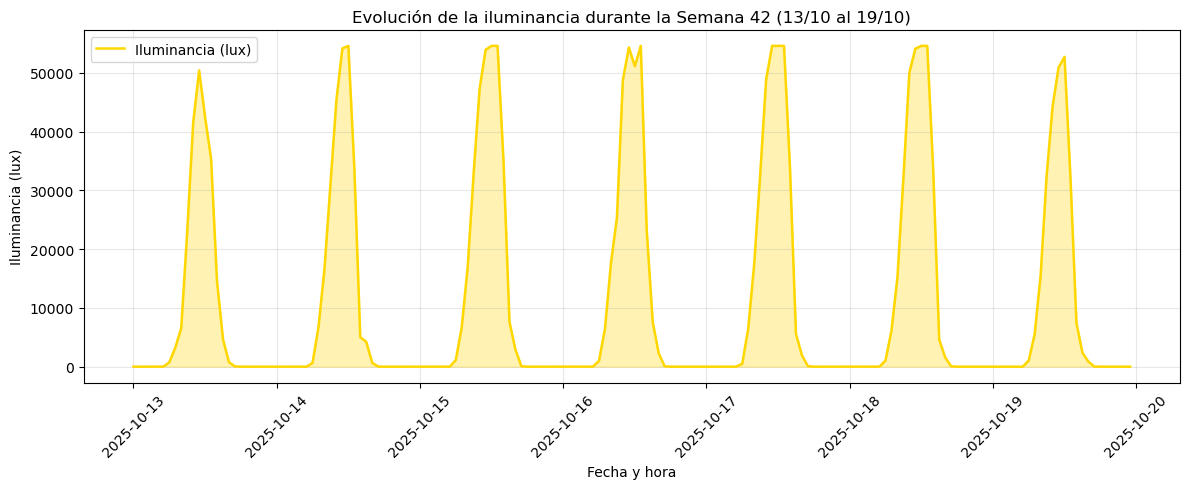

In [32]:

semana_42_1h = df_EDA[df_EDA['week'] == 42].resample('1H').mean(numeric_only=True)

ini = semana_42_1h.index.min()
fin = semana_42_1h.index.max()
titulo = f"Evolución de la iluminancia durante la Semana 42 ({ini:%d/%m} al {fin:%d/%m})"

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    semana_42_1h.index,
    semana_42_1h['lux'],
    color='gold',
    linewidth=1.8,
    label='Iluminancia (lux)'
)

ax.fill_between(semana_42_1h.index, semana_42_1h['lux'], color='gold', alpha=0.3)

ax.set_title(titulo)
ax.set_xlabel("Fecha y hora")
ax.set_ylabel("Iluminancia (lux)")
ax.grid(alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


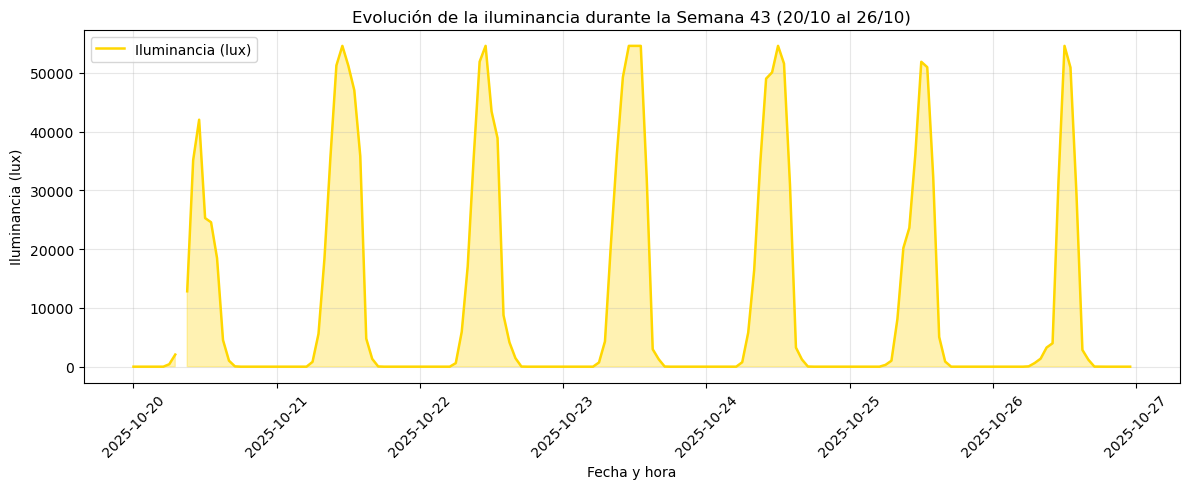

In [33]:

semana_43_1h = df_EDA[df_EDA['week'] == 43].resample('1H').mean(numeric_only=True)

ini = semana_43_1h.index.min()
fin = semana_43_1h.index.max()
titulo = f"Evolución de la iluminancia durante la Semana 43 ({ini:%d/%m} al {fin:%d/%m})"

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    semana_43_1h.index,
    semana_43_1h['lux'],
    color='gold',
    linewidth=1.8,
    label='Iluminancia (lux)'
)

ax.fill_between(semana_43_1h.index, semana_43_1h['lux'], color='gold', alpha=0.3)

ax.set_title(titulo)
ax.set_xlabel("Fecha y hora")
ax.set_ylabel("Iluminancia (lux)")
ax.grid(alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

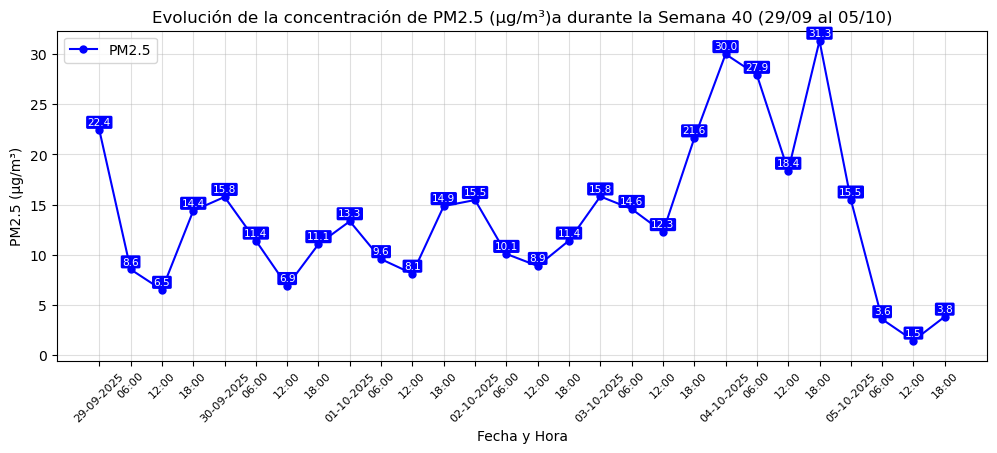

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_40 = df_EDA[df_EDA['week'] == 40].copy()
semana_40.index = pd.to_datetime(semana_40.index).floor('H')

semana_40_6h = semana_40.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_40_6h.index.min()
fin = semana_40_6h.index.max()
titulo = f"Evolución de la concentración de PM2.5 (µg/m³)a durante la Semana 40 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_40_6h.index,
    semana_40_6h['pm2.5'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='PM2.5'
)


for x, y in zip(semana_40_6h.index, semana_40_6h['pm2.5']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_40_6h['pm2.5'].min(), semana_40_6h['pm2.5'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()


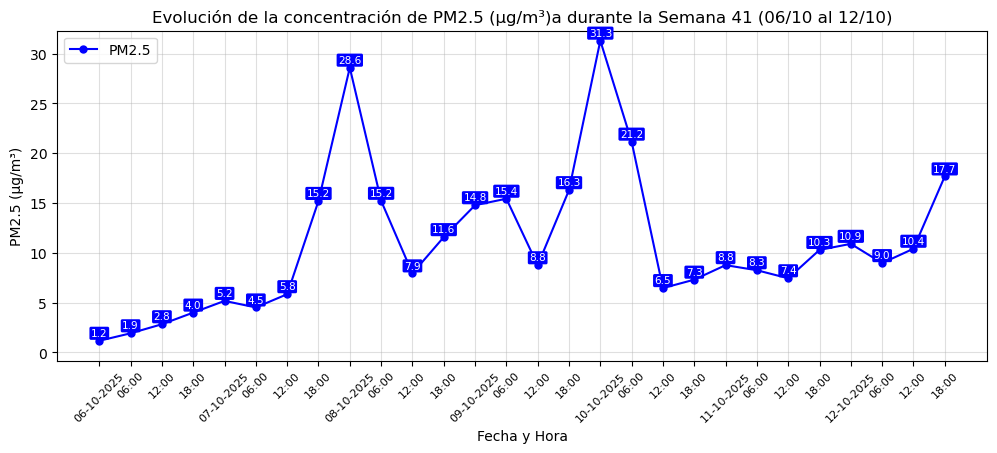

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_41 = df_EDA[df_EDA['week'] == 41].copy()
semana_41.index = pd.to_datetime(semana_41.index).floor('H')


semana_41_6h = semana_41.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_41_6h.index.min()
fin = semana_41_6h.index.max()
titulo = f"Evolución de la concentración de PM2.5 (µg/m³)a durante la Semana 41 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_41_6h.index,
    semana_41_6h['pm2.5'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='PM2.5'
)


for x, y in zip(semana_41_6h.index, semana_41_6h['pm2.5']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_41_6h['pm2.5'].min(), semana_41_6h['pm2.5'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()

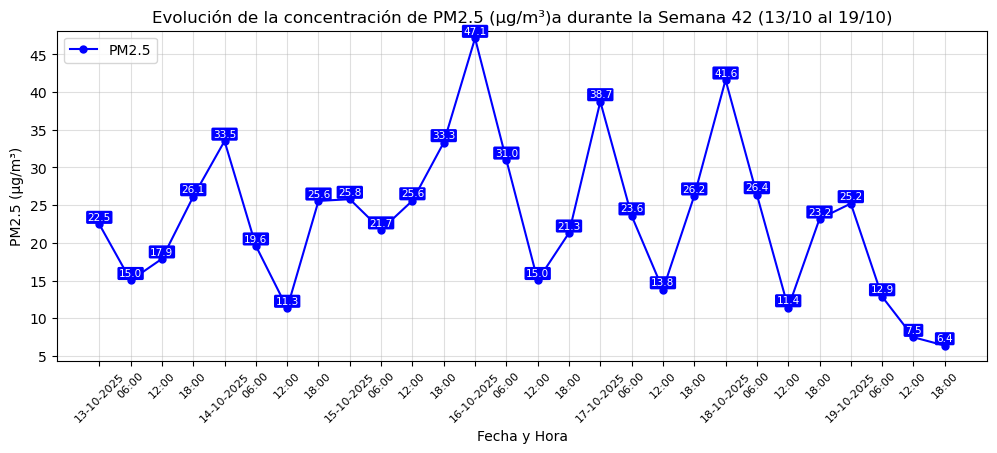

In [36]:

semana_42 = df_EDA[df_EDA['week'] == 42].copy()
semana_42.index = pd.to_datetime(semana_42.index).floor('H')


semana_42_6h = semana_42.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_42_6h.index.min()
fin = semana_42_6h.index.max()
titulo = f"Evolución de la concentración de PM2.5 (µg/m³)a durante la Semana 42 ({ini:%d/%m} al {fin:%d/%m})"



ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_42_6h.index,
    semana_42_6h['pm2.5'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='PM2.5'
)

for x, y in zip(semana_42_6h.index, semana_42_6h['pm2.5']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)

def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_42_6h['pm2.5'].min(), semana_42_6h['pm2.5'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()

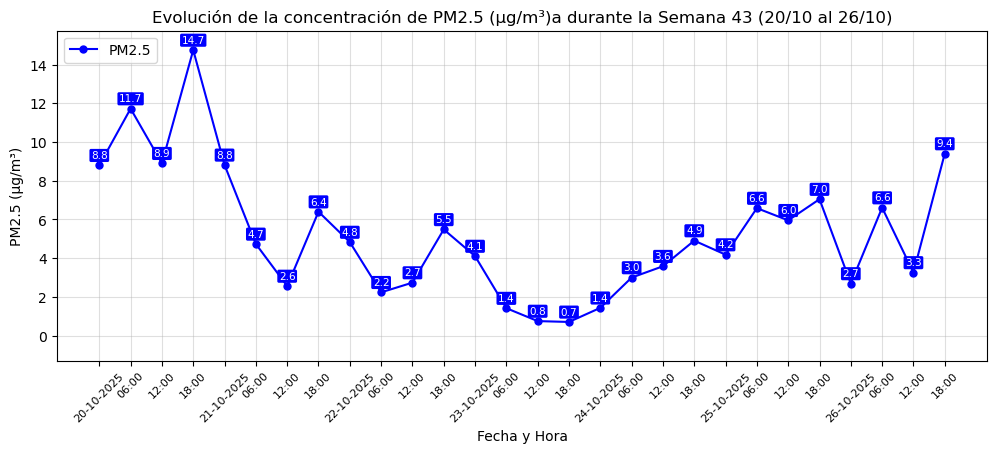

In [37]:

semana_43 = df_EDA[df_EDA['week'] == 43].copy()
semana_43.index = pd.to_datetime(semana_43.index).floor('H')


semana_43_6h = semana_43.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_43_6h.index.min()
fin = semana_43_6h.index.max()
titulo = f"Evolución de la concentración de PM2.5 (µg/m³)a durante la Semana 43 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_43_6h.index,
    semana_43_6h['pm2.5'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='PM2.5'
)


for x, y in zip(semana_43_6h.index, semana_43_6h['pm2.5']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))

# márgenes y estética
ymin, ymax = semana_43_6h['pm2.5'].min(), semana_43_6h['pm2.5'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()

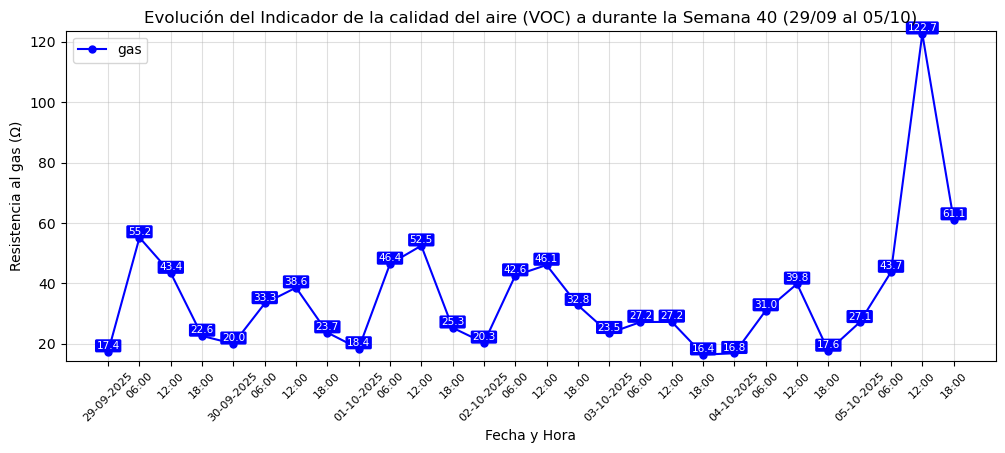

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_40 = df_EDA[df_EDA['week'] == 40].copy()
semana_40.index = pd.to_datetime(semana_40.index).floor('H')


semana_40_6h = semana_40.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_40_6h.index.min()
fin = semana_40_6h.index.max()
titulo = f"Evolución del Indicador de la calidad del aire (VOC) a durante la Semana 40 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_40_6h.index,
    semana_40_6h['gas'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='gas'
)

for x, y in zip(semana_40_6h.index, semana_40_6h['gas']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_40_6h['gas'].min(), semana_40_6h['gas'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Resistencia al gas (Ω)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()


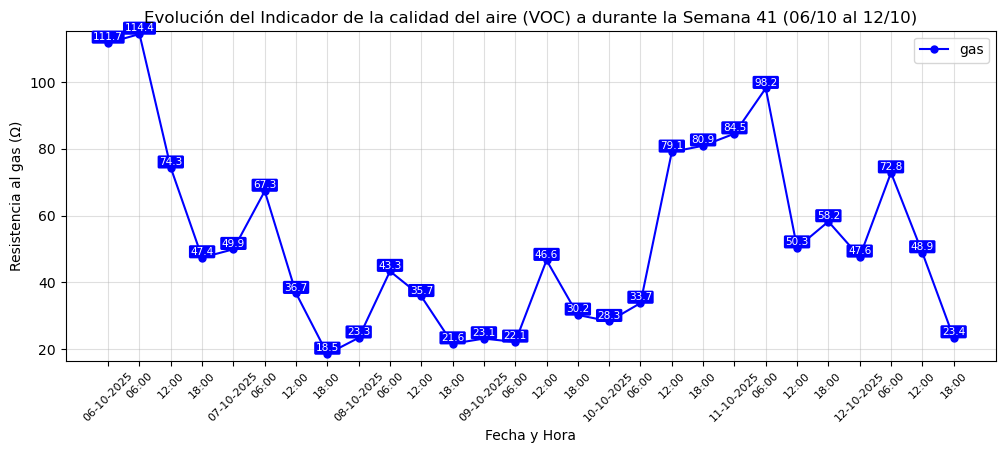

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_41 = df_EDA[df_EDA['week'] == 41].copy()
semana_41.index = pd.to_datetime(semana_41.index).floor('H')


semana_41_6h = semana_41.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_41_6h.index.min()
fin = semana_41_6h.index.max()
titulo = f"Evolución del Indicador de la calidad del aire (VOC) a durante la Semana 41 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_41_6h.index,
    semana_41_6h['gas'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='gas'
)


for x, y in zip(semana_41_6h.index, semana_41_6h['gas']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )

ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_41_6h['gas'].min(), semana_41_6h['gas'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Resistencia al gas (Ω)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()

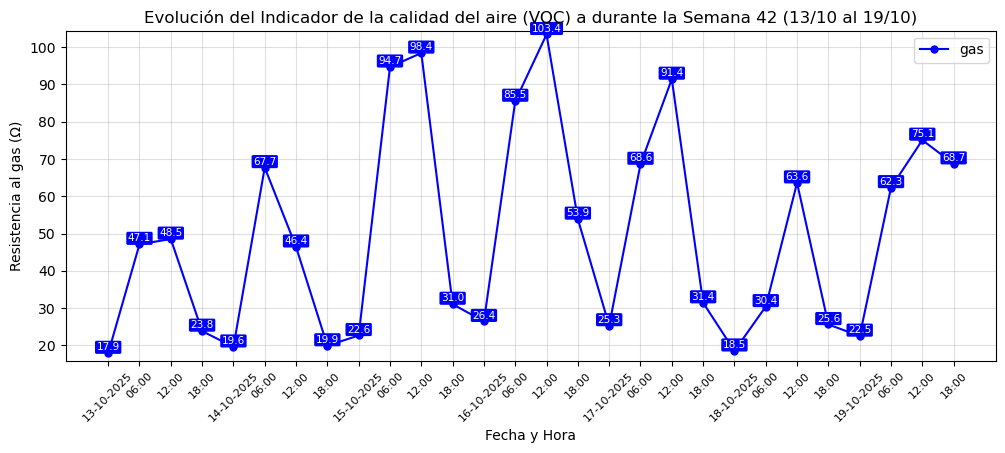

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_42 = df_EDA[df_EDA['week'] == 42].copy()
semana_42.index = pd.to_datetime(semana_42.index).floor('H')


semana_42_6h = semana_42.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_42_6h.index.min()
fin = semana_42_6h.index.max()
titulo = f"Evolución del Indicador de la calidad del aire (VOC) a durante la Semana 42 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_42_6h.index,
    semana_42_6h['gas'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='gas'
)


for x, y in zip(semana_42_6h.index, semana_42_6h['gas']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_42_6h['gas'].min(), semana_42_6h['gas'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Resistencia al gas (Ω)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()

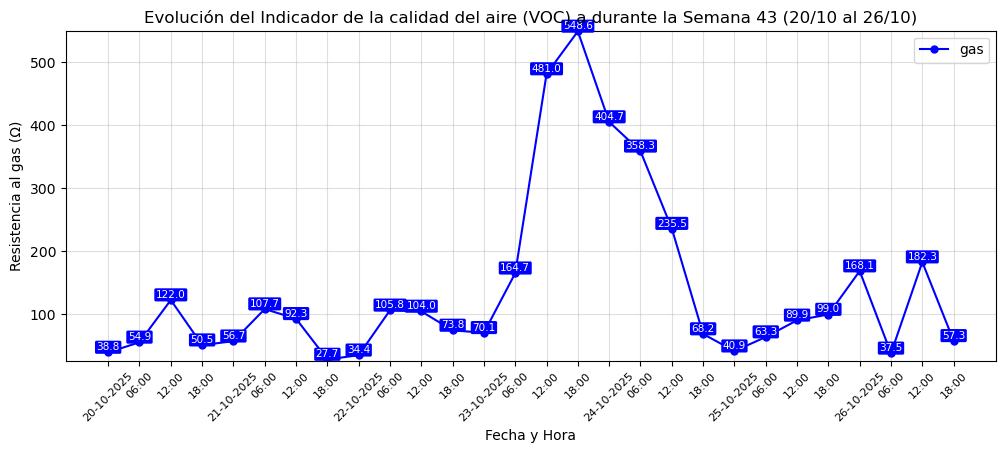

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_43 = df_EDA[df_EDA['week'] == 43].copy()
semana_43.index = pd.to_datetime(semana_43.index).floor('H')


semana_43_6h = semana_43.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_43_6h.index.min()
fin = semana_43_6h.index.max()
titulo = f"Evolución del Indicador de la calidad del aire (VOC) a durante la Semana 43 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_43_6h.index,
    semana_43_6h['gas'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='gas'
)


for x, y in zip(semana_43_6h.index, semana_43_6h['gas']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_43_6h['gas'].min(), semana_43_6h['gas'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Resistencia al gas (Ω)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()

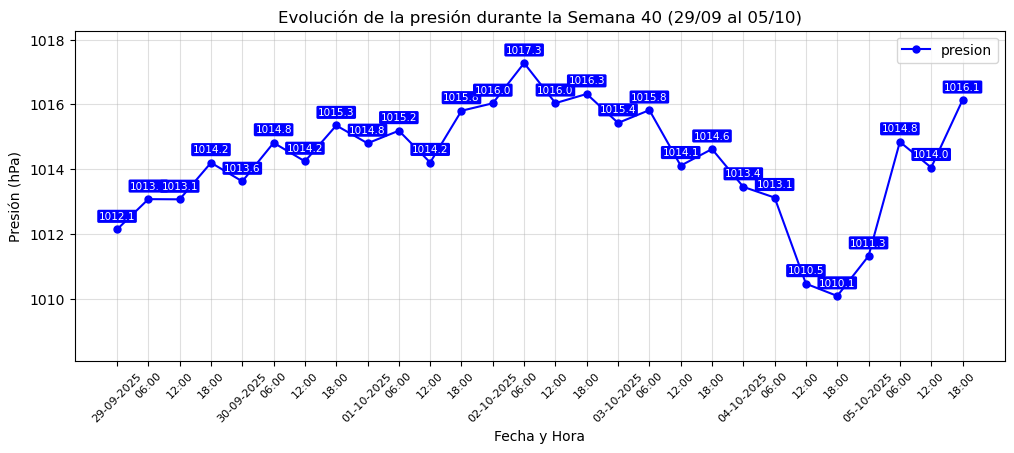

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

semana_40 = df_EDA[df_EDA['week'] == 40].copy()
semana_40.index = pd.to_datetime(semana_40.index).floor('H')


semana_40_6h = semana_40.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_40_6h.index.min()
fin = semana_40_6h.index.max()
titulo = f"Evolución de la presión durante la Semana 40 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_40_6h.index,
    semana_40_6h['presion'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='presion'
)


for x, y in zip(semana_40_6h.index, semana_40_6h['presion']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)

def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_40_6h['presion'].min(), semana_40_6h['presion'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Presión (hPa)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()


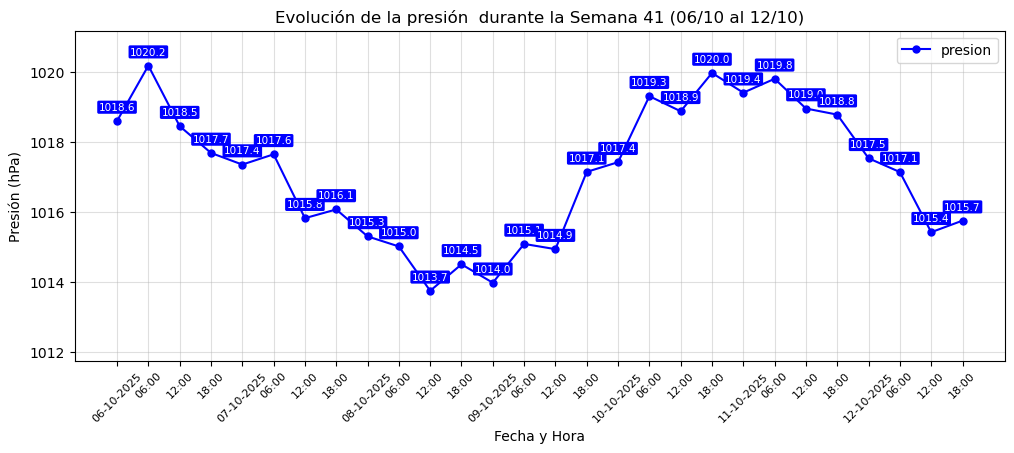

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_41 = df_EDA[df_EDA['week'] == 41].copy()
semana_41.index = pd.to_datetime(semana_41.index).floor('H')


semana_41_6h = semana_41.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_41_6h.index.min()
fin = semana_41_6h.index.max()
titulo = f"Evolución de la presión  durante la Semana 41 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_41_6h.index,
    semana_41_6h['presion'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='presion'
)


for x, y in zip(semana_41_6h.index, semana_41_6h['presion']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_41_6h['presion'].min(), semana_41_6h['presion'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Presión (hPa)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()

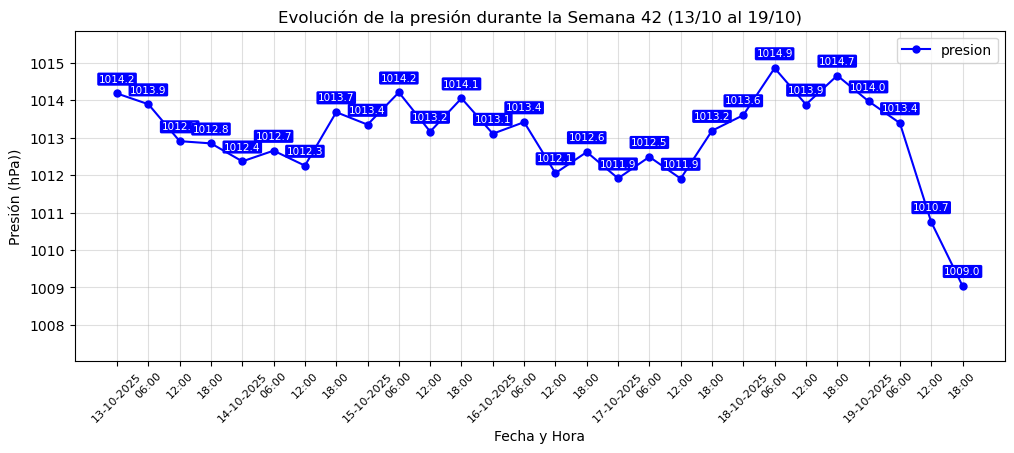

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_42 = df_EDA[df_EDA['week'] == 42].copy()
semana_42.index = pd.to_datetime(semana_42.index).floor('H')


semana_42_6h = semana_42.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_42_6h.index.min()
fin = semana_42_6h.index.max()
titulo = f"Evolución de la presión durante la Semana 42 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_42_6h.index,
    semana_42_6h['presion'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='presion'
)


for x, y in zip(semana_42_6h.index, semana_42_6h['presion']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_42_6h['presion'].min(), semana_42_6h['presion'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Presión (hPa))')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()

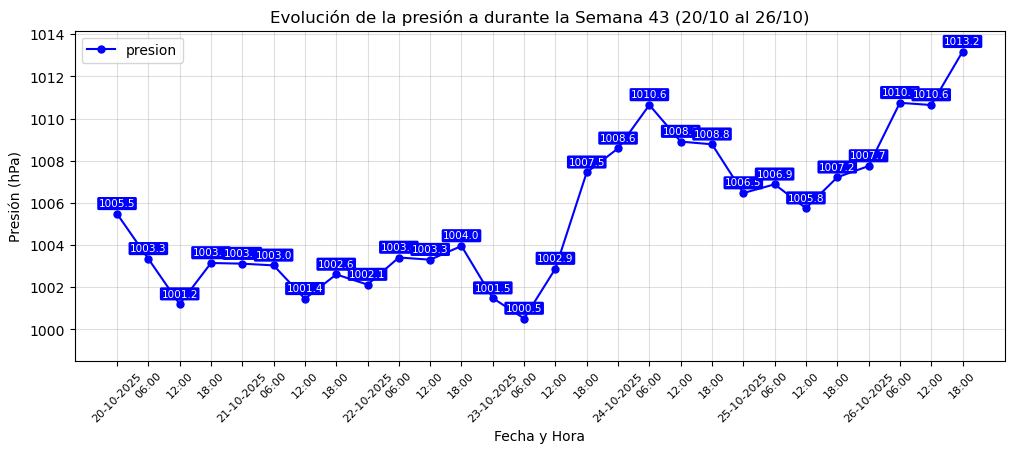

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


semana_43 = df_EDA[df_EDA['week'] == 43].copy()
semana_43.index = pd.to_datetime(semana_43.index).floor('H')


semana_43_6h = semana_43.resample('6H', origin='start_day').mean(numeric_only=True)

ini = semana_43_6h.index.min()
fin = semana_43_6h.index.max()
titulo = f"Evolución de la presión a durante la Semana 43 ({ini:%d/%m} al {fin:%d/%m})"


ticks = pd.date_range(start=ini, end=fin, freq='6H')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    semana_43_6h.index,
    semana_43_6h['presion'],
    color='blue',
    marker='o',
    markersize=5,
    linewidth=1.5,
    label='presion'
)


for x, y in zip(semana_43_6h.index, semana_43_6h['presion']):
    if pd.notna(y):
        ax.text(
            x, y + 0.25, f"{y:.1f}",
            ha='center', va='bottom', fontsize=7.5,
            color='white',
            bbox=dict(facecolor='blue', edgecolor='none', boxstyle='round,pad=0.15')
        )


ax.set_xticks(ticks)


def formato_fecha_hora(x, pos):
    dt = mdates.num2date(x)
    if dt.hour == 0:
        return dt.strftime('%d-%m-%Y')
    else:
        return dt.strftime('%H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(formato_fecha_hora))


ymin, ymax = semana_43_6h['presion'].min(), semana_43_6h['presion'].max()
ax.set_ylim(ymin - 2, ymax + 1)
ax.margins(x=0.05)

ax.set_title(titulo)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Presión (hPa)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.xticks(rotation=45, fontsize=8)
plt.subplots_adjust(bottom=0.22)
plt.show()

# Estadísticos descriptivos globales

In [46]:
resumen_reducido = df_EDA[['gas','humedad','lux','pm2.5','presion','temp']].agg(['mean', 'median', 'std', 'min', 'max']).T.round(0)
resumen_reducido


,mean,median,std,min,max
gas,69.0,42.0,86.0,7.0,628.0
humedad,69.0,72.0,15.0,17.0,94.0
lux,10511.0,2.0,18576.0,0.0,54612.0
pm2.5,13.0,10.0,11.0,0.0,62.0
presion,1013.0,1014.0,5.0,1000.0,1021.0
temp,21.0,21.0,4.0,12.0,36.0


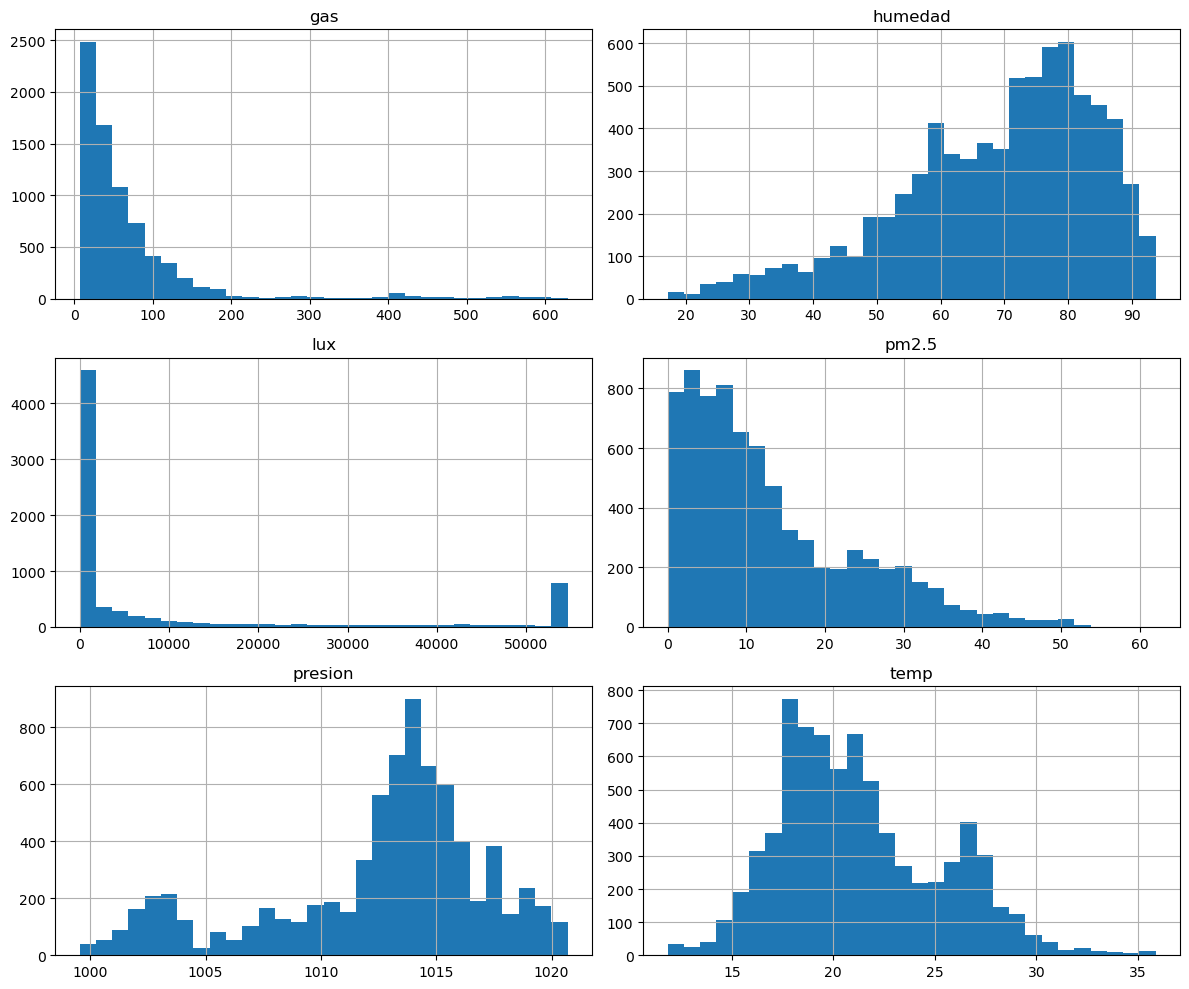

In [47]:
import matplotlib.pyplot as plt

df_EDA[['gas','humedad','lux','pm2.5','presion','temp']].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()


In [48]:
df_EDA.columns


Index(['gas', 'humedad', 'lux', 'pm10', 'pm1', 'pm2.5', 'presion', 'temp',
       'week'],
      dtype='object')

In [49]:
df_EDA

,gas,humedad,lux,pm10,pm1,pm2.5,presion,temp,week
Fecha/hora,,,,,,,,,
2025-09-29 00:02:53,16.10,80.73,0.83,20,14,19,1012.23,19.81,40
2025-09-29 00:08:26,16.22,80.81,0.83,22,14,20,1012.23,19.77,40
2025-09-29 00:13:58,16.02,80.96,0.83,22,14,20,1012.25,19.73,40
2025-09-29 00:19:31,15.80,80.77,0.83,25,16,22,1012.28,19.70,40
2025-09-29 00:25:11,15.80,80.58,0.83,22,15,20,1012.30,19.69,40
...,...,...,...,...,...,...,...,...,...
2025-10-26 23:35:48,118.88,71.84,0.83,3,2,3,1014.20,11.95,43
2025-10-26 23:41:25,143.41,69.92,0.83,3,2,2,1014.21,11.96,43
2025-10-26 23:47:00,163.57,69.40,0.83,2,1,2,1014.24,11.93,43


# Análisis de correlación entre variables

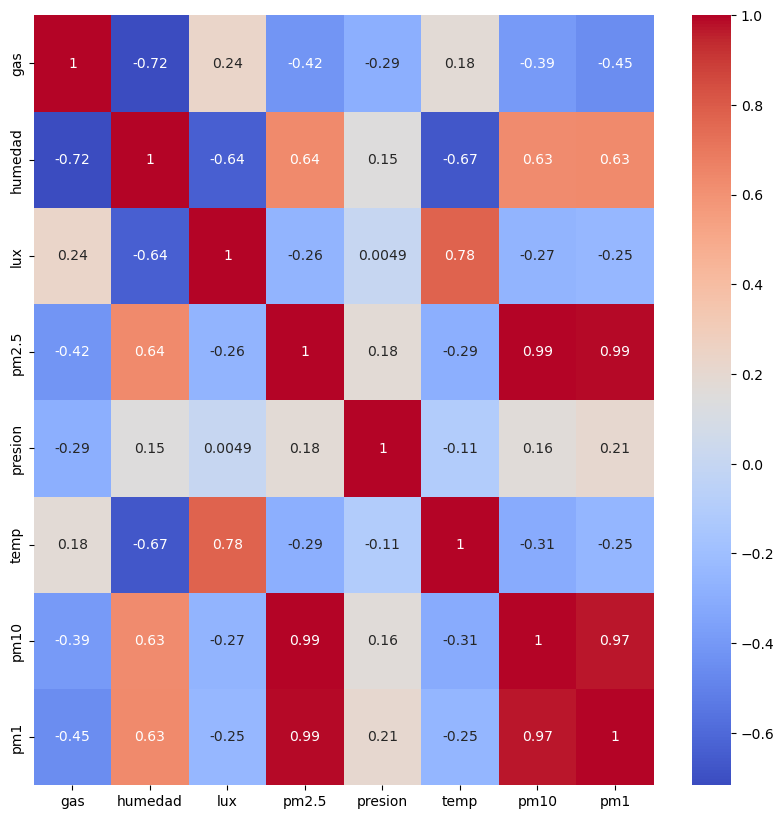

In [50]:

corr_matrix = df_EDA[['gas','humedad','lux','pm2.5','presion','temp','pm10','pm1']].corr()


plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

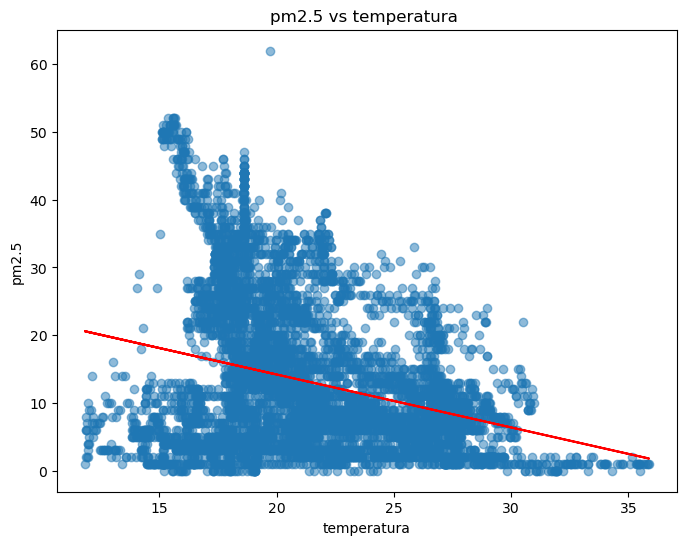

Ecuación de la recta:  
-0.7814 x + 29.83


In [51]:
import matplotlib.pyplot as plt
import numpy as np

x = df_EDA["temp"]
y = df_EDA["pm2.5"]

# Ajuste lineal
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, poly(x), color="red")  # línea de tendencia

plt.xlabel("temperatura")
plt.ylabel("pm2.5")
plt.title("pm2.5 vs temperatura ")

plt.show()

print("Ecuación de la recta:", poly)


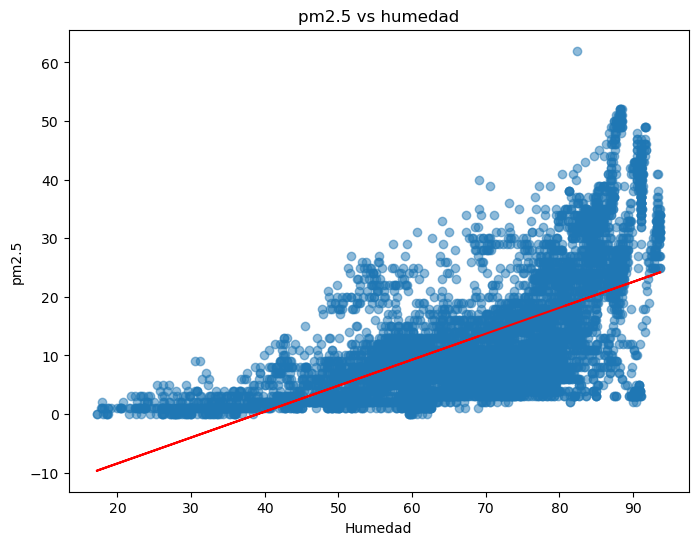

Ecuación de la recta:  
0.4428 x - 17.29


In [67]:
import matplotlib.pyplot as plt
import numpy as np

x = df_EDA["humedad"]
y = df_EDA["pm2.5"]

# Ajuste lineal
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, poly(x), color="red")  # línea de tendencia

plt.xlabel("Humedad")
plt.ylabel("pm2.5")
plt.title("pm2.5 vs humedad")

plt.show()

print("Ecuación de la recta:", poly)


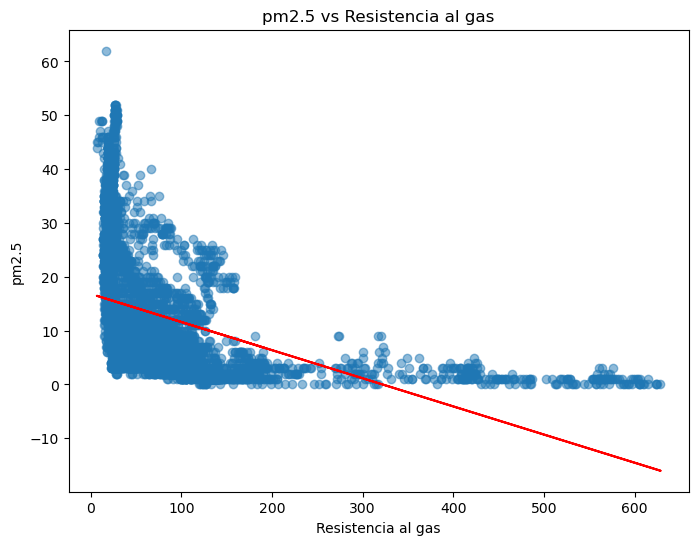

Ecuación de la recta:  
-0.05228 x + 16.83


In [68]:
import matplotlib.pyplot as plt
import numpy as np

x = df_EDA["gas"]
y = df_EDA["pm2.5"]

# Ajuste lineal
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, poly(x), color="red")  # línea de tendencia

plt.xlabel("Resistencia al gas")
plt.ylabel("pm2.5")
plt.title("pm2.5 vs Resistencia al gas")

plt.show()

print("Ecuación de la recta:", poly)

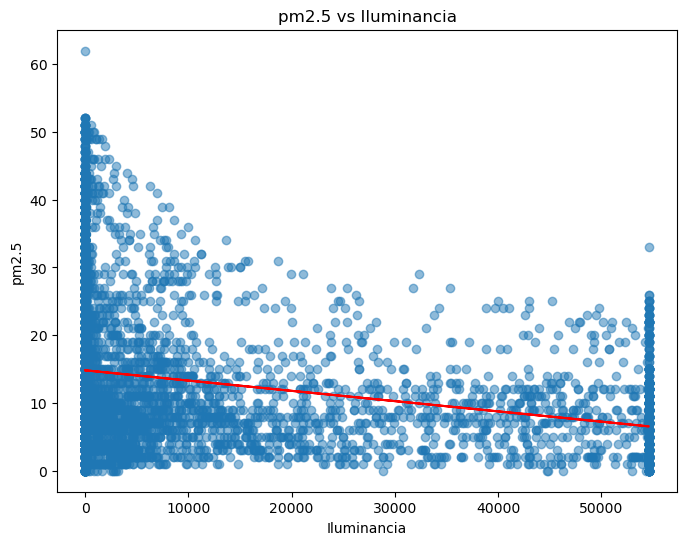

Ecuación de la recta:  
-0.0001515 x + 14.82


In [70]:
import matplotlib.pyplot as plt
import numpy as np

x = df_EDA["lux"]
y = df_EDA["pm2.5"]

# Ajuste lineal
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, poly(x), color="red")  # línea de tendencia

plt.xlabel("Iluminancia")
plt.ylabel("pm2.5")
plt.title("pm2.5 vs Iluminancia")

plt.show()

print("Ecuación de la recta:", poly)

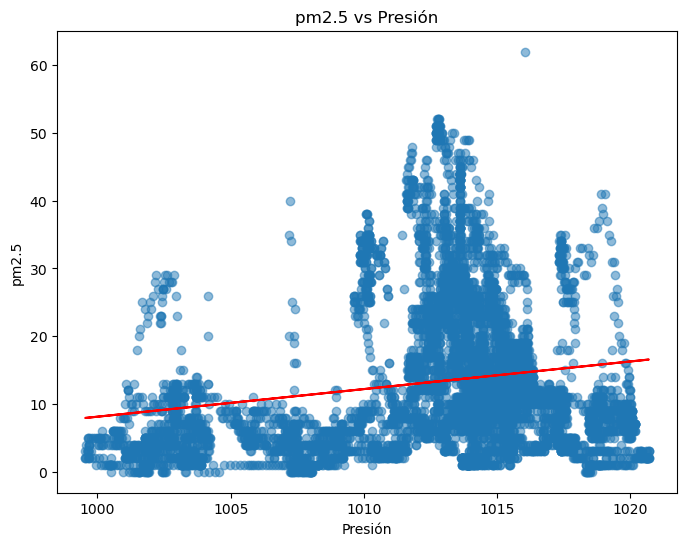

Ecuación de la recta:  
0.4077 x - 399.6


In [72]:
import matplotlib.pyplot as plt
import numpy as np

x = df_EDA["presion"]
y = df_EDA["pm2.5"]

# Ajuste lineal
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, poly(x), color="red")  # línea de tendencia

plt.xlabel("Presión")
plt.ylabel("pm2.5")
plt.title("pm2.5 vs Presión")

plt.show()

print("Ecuación de la recta:", poly)